In [9]:
import json
import config

# Đọc toàn bộ file log
log_file = config.LOG_FILE_PATH

samples = {}
with open(log_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            entry = json.loads(line)
            if "sample_id" in entry:
                samples[entry["sample_id"]] = entry
        except json.JSONDecodeError:
            continue

# Chọn mẫu theo ID (thay đổi id ở đây)
id = 0
if id in samples:
    print(json.dumps(samples[id], indent=2, ensure_ascii=False))
else:
    print(f"Sample ID {id} không tìm thấy. Các ID có sẵn: {sorted(samples.keys())}")


{
  "sample_id": 0,
  "original_id": "5726b929f1498d1400e8e8ea",
  "dataset_source": "European_Union_law",
  "input_data": {
    "query": "Which year was the case Commission v Italy that dealt with cocoa products?",
    "ground_truth": "2003",
    "context": "Often rules apply to all goods neutrally, but may have a greater practical effect on imports than domestic products. For such \"indirect\" discriminatory (or \"indistinctly applicable\") measures the Court of Justice has developed more justifications: either those in article 36, or additional \"mandatory\" or \"overriding\" requirements such as consumer protection, improving labour standards, protecting the environment, press diversity, fairness in commerce, and more: the categories are not closed. In the most famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, the Court of Justice found that a German law requiring all spirits and liqueurs (not just imported ones) to have a minimum alcohol content of 25 per cent was contra

In [10]:
print(json.dumps(samples[2], indent=2, ensure_ascii=False))


{
  "sample_id": 2,
  "original_id": "572699db5951b619008f779d",
  "dataset_source": "European_Union_law",
  "input_data": {
    "query": "What does the EU's legitimacy rest on?",
    "ground_truth": "the ultimate authority of member states, its factual commitment to human rights, and the democratic will of the people.",
    "context": "Generally speaking, while all member states recognise that EU law takes primacy over national law where this agreed in the Treaties, they do not accept that the Court of Justice has the final say on foundational constitutional questions affecting democracy and human rights. In the United Kingdom, the basic principle is that Parliament, as the sovereign expression of democratic legitimacy, can decide whether it wishes to expressly legislate against EU law. This, however, would only happen in the case of an express wish of the people to withdraw from the EU. It was held in R (Factortame Ltd) v Secretary of State for Transport that \"whatever limitation of

In [5]:
!pip install pandas

In [20]:
import pandas as pd
df = pd.read_csv('./result/results.csv')
df.head()

,sample_id,m1_latency,m2_latency,m3_latency,m1_total_input_token,m2_total_input_token,m3_total_input_token,m1_total_output_token,m2_total_output_token,m3_total_output_token,m1_k,m2_k,m3_k,m1_judge_score,m2_judge_score,m3_judge_score
0,0,2225.904465,2630.970955,4669.811964,187,787,949,18,32,63,3,10,10,1.00,1.0,1.0
1,1,1033.375978,2214.670181,4378.125668,406,238,396,15,30,60,3,1,1,1.00,1.0,1.0
2,2,1824.175358,1750.433683,4010.873556,256,847,1005,44,27,57,3,8,8,0.17,1.0,1.0
3,3,2456.235409,1999.267340,5175.770044,258,133,847,54,43,157,3,1,10,0.93,0.9,1.0
4,4,1259.629250,2785.019159,3632.112026,250,169,337,20,27,43,3,1,1,1.00,1.0,1.0


In [21]:
# TỔNG HỢP KẾT QUẢ
df = pd.read_csv('./result/results.csv')
n = len(df)

print(f"Samples: {n}\n")

# Latency
print("LATENCY (ms) - Mean:")
print(f"  M1: {df['m1_latency'].mean():.1f}, M2: {df['m2_latency'].mean():.1f}, M3: {df['m3_latency'].mean():.1f}\n")

# Tokens
print("INPUT TOKENS - Mean | Total:")
print(f"  M1: {df['m1_total_input_token'].mean():.0f} | {df['m1_total_input_token'].sum()}")
print(f"  M2: {df['m2_total_input_token'].mean():.0f} | {df['m2_total_input_token'].sum()}")
print(f"  M3: {df['m3_total_input_token'].mean():.0f} | {df['m3_total_input_token'].sum()}\n")

print("OUTPUT TOKENS - Mean | Total:")
print(f"  M1: {df['m1_total_output_token'].mean():.0f} | {df['m1_total_output_token'].sum()}")
print(f"  M2: {df['m2_total_output_token'].mean():.0f} | {df['m2_total_output_token'].sum()}")
print(f"  M3: {df['m3_total_output_token'].mean():.0f} | {df['m3_total_output_token'].sum()}\n")

# Score
print("AVG SCORE:")
print(f"  M1: {df['m1_judge_score'].mean():.3f}, M2: {df['m2_judge_score'].mean():.3f}, M3: {df['m3_judge_score'].mean():.3f}\n")

# Accuracy (>= 0.5 là đúng)
m1_acc = (df['m1_judge_score'] >= 0.5).sum() / n * 100
m2_acc = (df['m2_judge_score'] >= 0.5).sum() / n * 100
m3_acc = (df['m3_judge_score'] >= 0.5).sum() / n * 100
print("ACCURACY (score >= 0.5):")
print(f"  M1: {m1_acc:.1f}%, M2: {m2_acc:.1f}%, M3: {m3_acc:.1f}%")


Samples: 100

LATENCY (ms) - Mean:
  M1: 1727.7, M2: 2774.1, M3: 5027.7

INPUT TOKENS - Mean | Total:
  M1: 248 | 24826
  M2: 567 | 56730
  M3: 738 | 73810

OUTPUT TOKENS - Mean | Total:
  M1: 38 | 3782
  M2: 56 | 5554
  M3: 97 | 9690

AVG SCORE:
  M1: 0.828, M2: 0.888, M3: 0.908

ACCURACY (score >= 0.5):
  M1: 82.0%, M2: 89.0%, M3: 91.0%


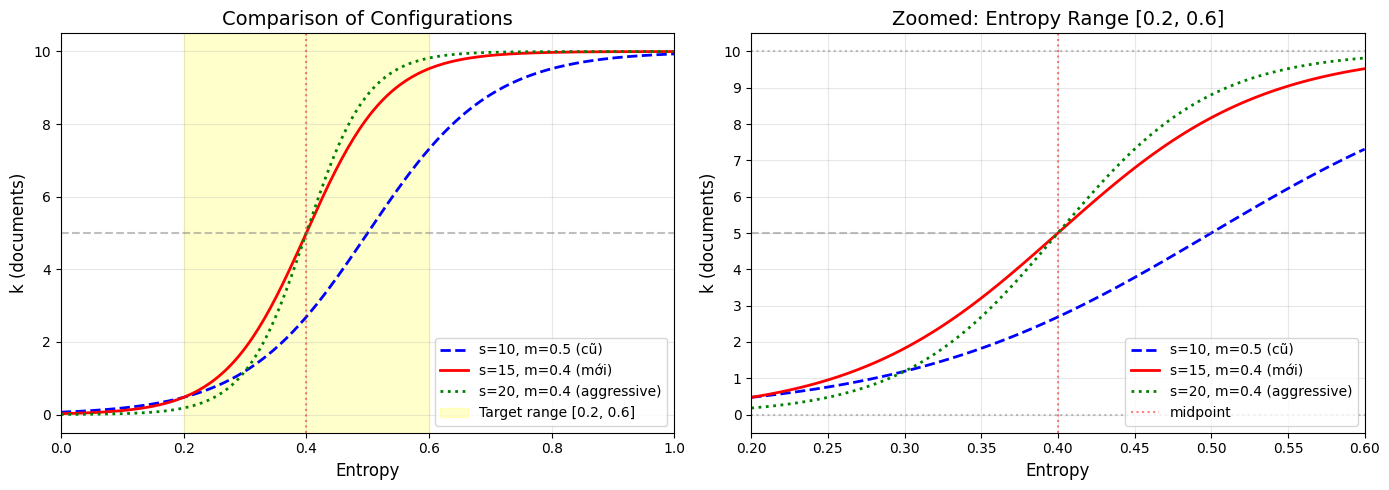


DETAILED COMPARISON FOR ENTROPY RANGE [0.2, 0.6]
Entropy    k (s=10,m=0.5)     k (s=15,m=0.4)     k (s=20,m=0.4)    
--------------------------------------------------------------------------------
0.20       0                  0                  0                 
0.25       1                  1                  0                 
0.30       1                  2                  1                 
0.35       2                  3                  3                 
0.40       3                  5                  5                 
0.45       4                  7                  7                 
0.50       5                  8                  9                 
0.55       6                  9                  10                
0.60       7                  10                 10                

COVERAGE ANALYSIS (k range used within entropy [0.2, 0.6])
s=10, m=0.5 (cũ): k=[0.5, 7.3] → 68.4% coverage
s=15, m=0.4 (mới): k=[0.5, 9.5] → 90.5% coverage
s=20, m=0.4 (aggressive): k=[0.2

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

def entropy_to_k(entropy, k_min=0, k_max=10, steepness=10, midpoint=0.5):
    s = 1 / (1 + math.exp(-steepness * (entropy - midpoint)))
    k = k_min + s * (k_max - k_min)
    return int(round(k))

def sigmoid_continuous(entropy, k_min=0, k_max=10, steepness=10, midpoint=0.5):
    s = 1 / (1 + math.exp(-steepness * (entropy - midpoint)))
    return k_min + s * (k_max - k_min)

# Generate data
entropy_values = np.linspace(0, 1, 200)

# Different configurations
configs = [
    {"steepness": 10, "midpoint": 0.5, "label": "s=10, m=0.5 (cũ)", "color": "blue", "linestyle": "--"},
    {"steepness": 15, "midpoint": 0.4, "label": "s=15, m=0.4 (mới)", "color": "red", "linestyle": "-"},
    {"steepness": 20, "midpoint": 0.4, "label": "s=20, m=0.4 (aggressive)", "color": "green", "linestyle": ":"},
]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full range comparison
for cfg in configs:
    k_vals = [sigmoid_continuous(e, steepness=cfg["steepness"], midpoint=cfg["midpoint"]) 
              for e in entropy_values]
    axes[0].plot(entropy_values, k_vals, color=cfg["color"], linestyle=cfg["linestyle"], 
                 linewidth=2, label=cfg["label"])

# Highlight the target range
axes[0].axvspan(0.2, 0.6, alpha=0.2, color='yellow', label='Target range [0.2, 0.6]')
axes[0].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0.4, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Entropy', fontsize=12)
axes[0].set_ylabel('k (documents)', fontsize=12)
axes[0].set_title('Comparison of Configurations', fontsize=14)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-0.5, 10.5)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='lower right')

# Plot 2: Zoomed into target range [0.2, 0.6]
entropy_zoom = np.linspace(0.2, 0.6, 100)
for cfg in configs:
    k_vals = [sigmoid_continuous(e, steepness=cfg["steepness"], midpoint=cfg["midpoint"]) 
              for e in entropy_zoom]
    axes[1].plot(entropy_zoom, k_vals, color=cfg["color"], linestyle=cfg["linestyle"], 
                 linewidth=2, label=cfg["label"])

axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=10, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.4, color='red', linestyle=':', alpha=0.5, label='midpoint')
axes[1].set_xlabel('Entropy', fontsize=12)
axes[1].set_ylabel('k (documents)', fontsize=12)
axes[1].set_title('Zoomed: Entropy Range [0.2, 0.6]', fontsize=14)
axes[1].set_xlim(0.2, 0.6)
axes[1].set_ylim(-0.5, 10.5)
axes[1].set_yticks(range(0, 11))
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Print detailed table
print("\n" + "=" * 80)
print("DETAILED COMPARISON FOR ENTROPY RANGE [0.2, 0.6]")
print("=" * 80)
print(f"{'Entropy':<10} {'k (s=10,m=0.5)':<18} {'k (s=15,m=0.4)':<18} {'k (s=20,m=0.4)':<18}")
print("-" * 80)
for e in np.arange(0.20, 0.65, 0.05):
    k1 = entropy_to_k(e, steepness=10, midpoint=0.5)
    k2 = entropy_to_k(e, steepness=15, midpoint=0.4)
    k3 = entropy_to_k(e, steepness=20, midpoint=0.4)
    print(f"{e:<10.2f} {k1:<18} {k2:<18} {k3:<18}")

# Coverage analysis
print("\n" + "=" * 80)
print("COVERAGE ANALYSIS (k range used within entropy [0.2, 0.6])")
print("=" * 80)
for cfg in configs:
    k_at_02 = sigmoid_continuous(0.2, steepness=cfg["steepness"], midpoint=cfg["midpoint"])
    k_at_06 = sigmoid_continuous(0.6, steepness=cfg["steepness"], midpoint=cfg["midpoint"])
    coverage = (k_at_06 - k_at_02) / 10 * 100
    print(f"{cfg['label']}: k=[{k_at_02:.1f}, {k_at_06:.1f}] → {coverage:.1f}% coverage")

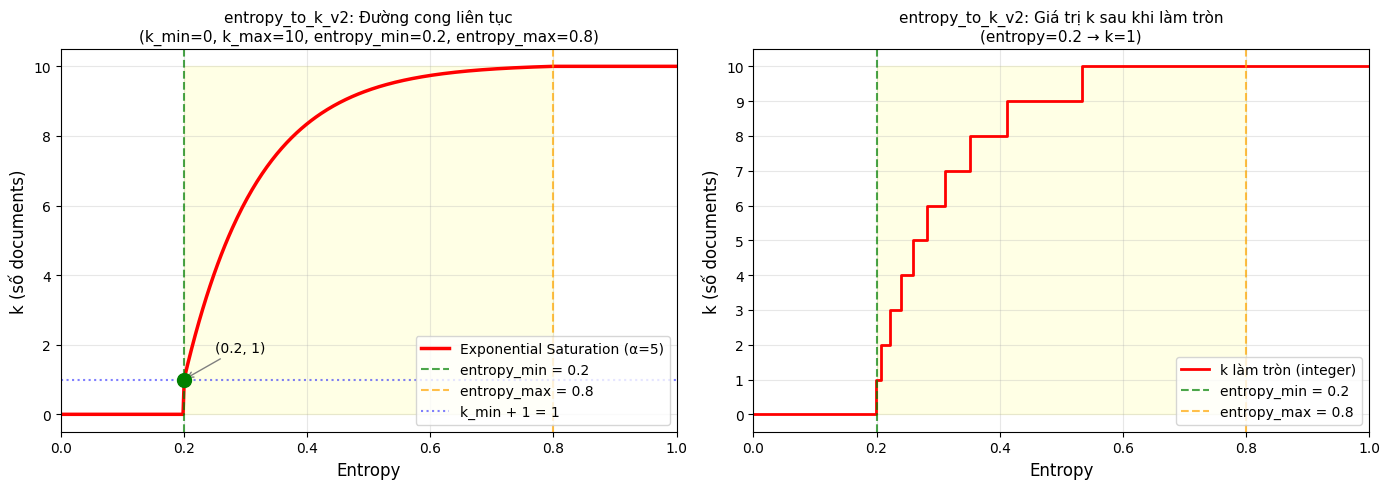


=== Bảng giá trị entropy -> k (hàm mới) ===
Entropy    k (continuous)  k (rounded)
-----------------------------------
0.00       0.00            0         
0.10       0.00            0         
0.20       1.00            1         
0.25       4.09            4         
0.30       6.12            6         
0.40       8.35            8         
0.50       9.32            9         
0.60       9.74            10        
0.70       9.92            10        
0.80       10.00           10        
0.90       10.00           10        
1.00       10.00           10        


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

def entropy_to_k_v2(entropy, k_min=0, k_max=10, entropy_min=0.2, entropy_max=0.8, alpha=2):
    """
    Map entropy to k using exponential saturation curve.
    
    Logic:
    - entropy < entropy_min  → k = k_min
    - entropy = entropy_min  → k = k_min + 1
    - entropy tăng dần      → k tăng từ (k_min+1) đến k_max
    - entropy >= entropy_max → k = k_max
    
    Parameters:
    - entropy: float, giá trị entropy
    - k_min: minimum documents khi entropy rất thấp (default 0)
    - k_max: maximum documents (default 10)
    - entropy_min: ngưỡng bắt đầu retrieve (default 0.2)
    - entropy_max: ngưỡng retrieve tối đa (default 0.8)
    - alpha: độ dốc, càng cao càng dốc ban đầu (default 5)
    
    Returns:
    - k: int, số document để retrieve
    """
    # Dưới ngưỡng min → không retrieve
    if entropy < entropy_min:
        return k_min
    
    # Trên ngưỡng max → retrieve tối đa
    if entropy >= entropy_max:
        return k_max
    
    # Normalize entropy to [0, 1]
    t = (entropy - entropy_min) / (entropy_max - entropy_min)
    
    # Exponential saturation, normalized để f(0)=0, f(1)=1
    # f(t) = (1 - exp(-α*t)) / (1 - exp(-α))
    f_t = (1 - math.exp(-alpha * t)) / (1 - math.exp(-alpha))
    
    # Map từ (k_min + 1) đến k_max
    # Tại t=0 (entropy=entropy_min): k = k_min + 1
    # Tại t=1 (entropy=entropy_max): k = k_max
    k_range = k_max - k_min - 1  # range từ (k_min+1) đến k_max
    k_continuous = (k_min + 1) + k_range * f_t
    
    return int(round(k_continuous))


def entropy_to_k_v2_continuous(entropy, k_min=0, k_max=10, entropy_min=0.2, entropy_max=0.8, alpha=2):
    """Version không làm tròn để vẽ đường cong mượt."""
    entropy = np.asarray(entropy)
    result = np.full_like(entropy, float(k_min), dtype=float)
    
    # Above entropy_max
    result[entropy >= entropy_max] = k_max
    
    # In between [entropy_min, entropy_max)
    mask = (entropy >= entropy_min) & (entropy < entropy_max)
    t = (entropy[mask] - entropy_min) / (entropy_max - entropy_min)
    
    # Normalized exponential saturation
    f_t = (1 - np.exp(-alpha * t)) / (1 - np.exp(-alpha))
    
    k_range = k_max - k_min - 1
    result[mask] = (k_min + 1) + k_range * f_t
    
    return result


# ========================
# VISUALIZATION
# ========================

entropy_values = np.linspace(0.0, 1.0, 500)
k_new = entropy_to_k_v2_continuous(entropy_values, alpha=5)
k_discrete = [entropy_to_k_v2(e, alpha=5) for e in entropy_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Đường cong liên tục
ax1 = axes[0]
ax1.plot(entropy_values, k_new, 'r-', linewidth=2.5, label='Exponential Saturation (α=5)')
ax1.axvline(x=0.2, color='green', linestyle='--', alpha=0.7, label='entropy_min = 0.2')
ax1.axvline(x=0.8, color='orange', linestyle='--', alpha=0.7, label='entropy_max = 0.8')
ax1.axhline(y=1, color='blue', linestyle=':', alpha=0.5, label='k_min + 1 = 1')
ax1.scatter([0.2], [1], color='green', s=100, zorder=5, marker='o')
ax1.annotate('(0.2, 1)', xy=(0.2, 1), xytext=(0.25, 1.8), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'))
ax1.fill_betweenx([0, 10], 0.2, 0.8, alpha=0.1, color='yellow')
ax1.set_xlabel('Entropy', fontsize=12)
ax1.set_ylabel('k (số documents)', fontsize=12)
ax1.set_title('entropy_to_k_v2: Đường cong liên tục\n(k_min=0, k_max=10, entropy_min=0.2, entropy_max=0.8)', fontsize=11)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-0.5, 10.5)

# Plot 2: Giá trị k làm tròn
ax2 = axes[1]
ax2.step(entropy_values, k_discrete, 'r-', linewidth=2, where='mid', label='k làm tròn (integer)')
ax2.axvline(x=0.2, color='green', linestyle='--', alpha=0.7, label='entropy_min = 0.2')
ax2.axvline(x=0.8, color='orange', linestyle='--', alpha=0.7, label='entropy_max = 0.8')
ax2.fill_betweenx([0, 10], 0.2, 0.8, alpha=0.1, color='yellow')
ax2.set_xlabel('Entropy', fontsize=12)
ax2.set_ylabel('k (số documents)', fontsize=12)
ax2.set_title('entropy_to_k_v2: Giá trị k sau khi làm tròn\n(entropy=0.2 → k=1)', fontsize=11)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-0.5, 10.5)
ax2.set_yticks(range(0, 11))

plt.tight_layout()
plt.show()

# Bảng giá trị
print("\n=== Bảng giá trị entropy -> k (hàm mới) ===")
print(f"{'Entropy':<10} {'k (continuous)':<15} {'k (rounded)':<10}")
print("-" * 35)
for e in [0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    k_cont = entropy_to_k_v2_continuous(np.array([e]), alpha=5)[0]
    k_int = entropy_to_k_v2(e, alpha=5)
    print(f"{e:<10.2f} {k_cont:<15.2f} {k_int:<10}")

In [8]:

print("\n34. So, in a 2009 case, Commission v Italy, the Court of Justice\n\n03 case, Commission v Italy Italian law required that cocoa prod\n\nost famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, \n\ny applicable\") measures the Court of Justice has developed more \n\nbstitute\". All Italian chocolate was made from cocoa butter alon\n\nCâu hỏi: Which year was the case Commission v Italy that dealt with cocoa products?")


34. So, in a 2009 case, Commission v Italy, the Court of Justice

03 case, Commission v Italy Italian law required that cocoa prod

ost famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, 

y applicable") measures the Court of Justice has developed more 

bstitute". All Italian chocolate was made from cocoa butter alon

Câu hỏi: Which year was the case Commission v Italy that dealt with cocoa products?


In [9]:
print("n = 5 \n")
print("\n34. So, in a 2009 case, Commission v Italy, the Court of Justice\n\n03 case, Commission v Italy Italian law required that cocoa prod\n\nost famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, \n\ny applicable\") measures the Court of Justice has developed more \n\nCâu hỏi: Which year was the case Commission v Italy that dealt with cocoa products?")


n = 5 


34. So, in a 2009 case, Commission v Italy, the Court of Justice

03 case, Commission v Italy Italian law required that cocoa prod

ost famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, 

y applicable") measures the Court of Justice has developed more 

Câu hỏi: Which year was the case Commission v Italy that dealt with cocoa products?


In [10]:

print("Often rules apply to all goods neutrally, but may have a greater practical effect on imports than domestic products. For such \"indirect\" discriminatory (or \"indistinctly applicable\") measures the Court of Justice has developed more justifications: either those in article 36, or additional \"mandatory\" or \"overriding\" requirements such as consumer protection, improving labour standards, protecting the environment, press diversity, fairness in commerce, and more: the categories are not closed. In the most famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, the Court of Justice found that a German law requiring all spirits and liqueurs (not just imported ones) to have a minimum alcohol content of 25 per cent was contrary to TFEU article 34, because it had a greater negative effect on imports. German liqueurs were over 25 per cent alcohol, but Cassis de Dijon, which Rewe-Zentrale AG wished to import from France, only had 15 to 20 per cent alcohol. The Court of Justice rejected the German government's arguments that the measure proportionately protected public health under TFEU article 36, because stronger beverages were available and adequate labelling would be enough for consumers to understand what they bought. This rule primarily applies to requirements about a product's content or packaging. In Walter Rau Lebensmittelwerke v De Smedt PVBA the Court of Justice found that a Belgian law requiring all margarine to be in cube shaped packages infringed article 34, and was not justified by the pursuit of consumer protection. The argument that Belgians would believe it was butter if it was not cube shaped was disproportionate: it would \"considerably exceed the requirements of the object in view\" and labelling would protect consumers \"just as effectively\". In a 2003 case, Commission v Italy Italian law required that cocoa products that included other vegetable fats could not be labelled as \"chocolate\". It had to be \"chocolate substitute\". All Italian chocolate was made from cocoa butter alone, but British, Danish and Irish manufacturers used other vegetable fats. They claimed the law infringed article 34. The Court of Justice held that a low content of vegetable fat did not justify a \"chocolate substitute\" label. This was derogatory in the consumers' eyes. A neutral and objective statement was enough to protect consumers. If member states place considerable obstacles on the use of a product, this can also infringe article 34. So, in a 2009 case, Commission v Italy, the Court of Justice held that an Italian law prohibiting motorcycles or mopeds pulling trailers infringed article 34. Again, the law applied neutrally to everyone, but disproportionately affected importers, because Italian companies did not make trailers. This was not a product requirement, but the Court reasoned that the prohibition would deter people from buying it: it would have \"a considerable influence on the behaviour of consumers\" that \"affects the access of that product to the market\". It would require justification under article 36, or as a mandatory requirement.")

Often rules apply to all goods neutrally, but may have a greater practical effect on imports than domestic products. For such "indirect" discriminatory (or "indistinctly applicable") measures the Court of Justice has developed more justifications: either those in article 36, or additional "mandatory" or "overriding" requirements such as consumer protection, improving labour standards, protecting the environment, press diversity, fairness in commerce, and more: the categories are not closed. In the most famous case Rewe-Zentral AG v Bundesmonopol für Branntwein, the Court of Justice found that a German law requiring all spirits and liqueurs (not just imported ones) to have a minimum alcohol content of 25 per cent was contrary to TFEU article 34, because it had a greater negative effect on imports. German liqueurs were over 25 per cent alcohol, but Cassis de Dijon, which Rewe-Zentrale AG wished to import from France, only had 15 to 20 per cent alcohol. The Court of Justice rejected the G